# ECoG Data Exploration and Preprocessing

This notebook explores the Precision Layer 7 micro-ECoG dataset from primary auditory cortex recordings.

**Dataset characteristics:**
- 1024 channels from a high-density micro-ECoG array
- 1000 Hz sampling rate
- Task: Classify auditory stimulus frequency from neural signals

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal
from scipy.stats import zscore

# Project imports
import sys
sys.path.insert(0, str(Path.cwd().parent))

from brainstorm.download import download_train_validation_data
from brainstorm.loading import load_raw_data, load_channel_coordinates
from brainstorm.plotting import dot_plot
from brainstorm.spatial import channels_to_spatial
from brainstorm.constants import N_CHANNELS, SAMPLING_RATE, GRID_HEIGHT, GRID_WIDTH

plt.style.use('fivethirtyeight')
%matplotlib inline

## 1. Load the Data

In [9]:
DATA_PATH = Path("./data")

# Download if not present
if not DATA_PATH.exists() or not any(DATA_PATH.glob("*.parquet")):
    print("Downloading data from Hugging Face...")
    download_train_validation_data()
    print("Done!")

# Load training and validation data
train_features, train_labels = load_raw_data(DATA_PATH, step="train")
val_features, val_labels = load_raw_data(DATA_PATH, step="validation")

# Load electrode coordinates
channel_coords = load_channel_coordinates()

2026-01-23 12:15:21.176 | INFO     | brainstorm.loading:load_raw_data:38 - Loading data from: data
2026-01-23 12:15:21.309 | INFO     | brainstorm.loading:load_raw_data:50 - Features shape: (90386, 1024)
2026-01-23 12:15:21.309 | INFO     | brainstorm.loading:load_raw_data:51 - Labels shape: (90386, 1)
2026-01-23 12:15:21.309 | INFO     | brainstorm.loading:load_raw_data:54 - Features time range: 0.0 to 90.385
2026-01-23 12:15:21.310 | INFO     | brainstorm.loading:load_raw_data:57 - Labels time range: 0.0 to 90.385
2026-01-23 12:15:21.313 | INFO     | brainstorm.loading:load_raw_data:38 - Loading data from: data
2026-01-23 12:15:21.372 | INFO     | brainstorm.loading:load_raw_data:50 - Features shape: (22596, 1024)
2026-01-23 12:15:21.372 | INFO     | brainstorm.loading:load_raw_data:51 - Labels shape: (22596, 1)
2026-01-23 12:15:21.372 | INFO     | brainstorm.loading:load_raw_data:54 - Features time range: 90.387 to 112.982
2026-01-23 12:15:21.373 | INFO     | brainstorm.loading:load

## 2. Dataset Overview

In [10]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTraining Data:")
print(f"  Features shape: {train_features.shape}")
print(f"  Labels shape: {train_labels.shape}")
print(f"  Time range: {train_features.index[0]:.2f}s to {train_features.index[-1]:.2f}s")
print(f"  Duration: {train_features.index[-1] - train_features.index[0]:.2f}s")

print(f"\nValidation Data:")
print(f"  Features shape: {val_features.shape}")
print(f"  Labels shape: {val_labels.shape}")
print(f"  Time range: {val_features.index[0]:.2f}s to {val_features.index[-1]:.2f}s")
print(f"  Duration: {val_features.index[-1] - val_features.index[0]:.2f}s")

print(f"\nRecording Parameters:")
print(f"  Number of channels: {N_CHANNELS}")
print(f"  Sampling rate: {SAMPLING_RATE} Hz")
print(f"  Grid dimensions: {GRID_HEIGHT} x {GRID_WIDTH}")

DATASET OVERVIEW

Training Data:
  Features shape: (90386, 1024)
  Labels shape: (90386, 1)
  Time range: 0.00s to 90.39s
  Duration: 90.39s

Validation Data:
  Features shape: (22596, 1024)
  Labels shape: (22596, 1)
  Time range: 90.39s to 112.98s
  Duration: 22.59s

Recording Parameters:
  Number of channels: 1024
  Sampling rate: 1000 Hz
  Grid dimensions: 31 x 32


In [11]:
# Label distribution
print("\nLabel Distribution (Training):")
label_counts = train_labels['label'].value_counts().sort_index()
for label, count in label_counts.items():
    pct = 100 * count / len(train_labels)
    print(f"  {int(label):5d} Hz: {count:6d} samples ({pct:5.1f}%)")


Label Distribution (Training):
      0 Hz:  60454 samples ( 66.9%)
    120 Hz:   3670 samples (  4.1%)
    224 Hz:   3668 samples (  4.1%)
    421 Hz:   3674 samples (  4.1%)
    789 Hz:   3853 samples (  4.3%)
   1479 Hz:   3851 samples (  4.3%)
   2772 Hz:   3853 samples (  4.3%)
   5195 Hz:   3697 samples (  4.1%)
   9736 Hz:   3666 samples (  4.1%)


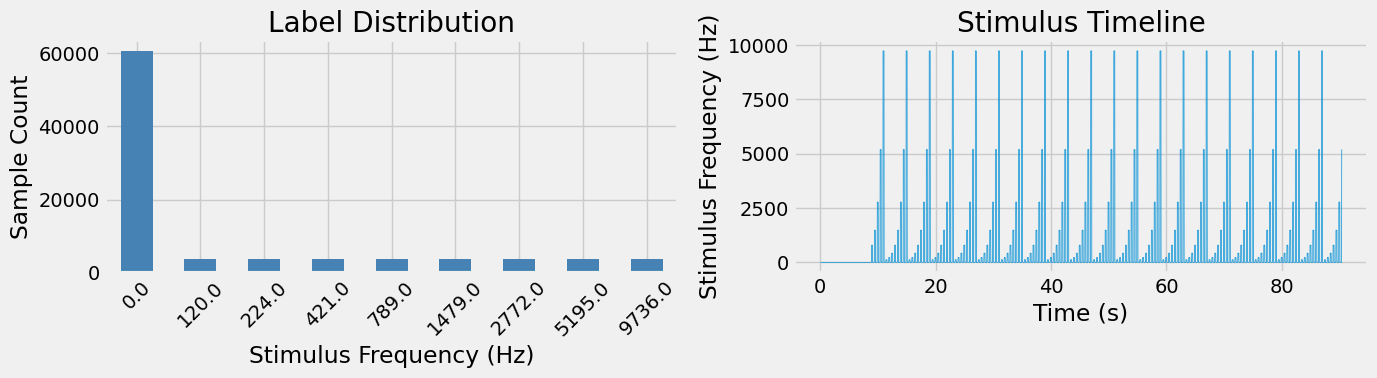

In [12]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
ax = axes[0]
label_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Stimulus Frequency (Hz)')
ax.set_ylabel('Sample Count')
ax.set_title('Label Distribution')
ax.tick_params(axis='x', rotation=45)

# Timeline
ax = axes[1]
ax.plot(train_labels.index, train_labels['label'], linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Stimulus Frequency (Hz)')
ax.set_title('Stimulus Timeline')

plt.tight_layout()
plt.show()

## 3. Electrode Array Layout

In [13]:
print("Channel Coordinates:")
print(f"  Shape: {channel_coords.shape}")
print(f"  X range: {channel_coords[:, 0].min():.1f} to {channel_coords[:, 0].max():.1f}")
print(f"  Y range: {channel_coords[:, 1].min():.1f} to {channel_coords[:, 1].max():.1f}")

Channel Coordinates:
  Shape: (1024, 2)
  X range: -3.0 to 35.0
  Y range: -2.0 to 35.0


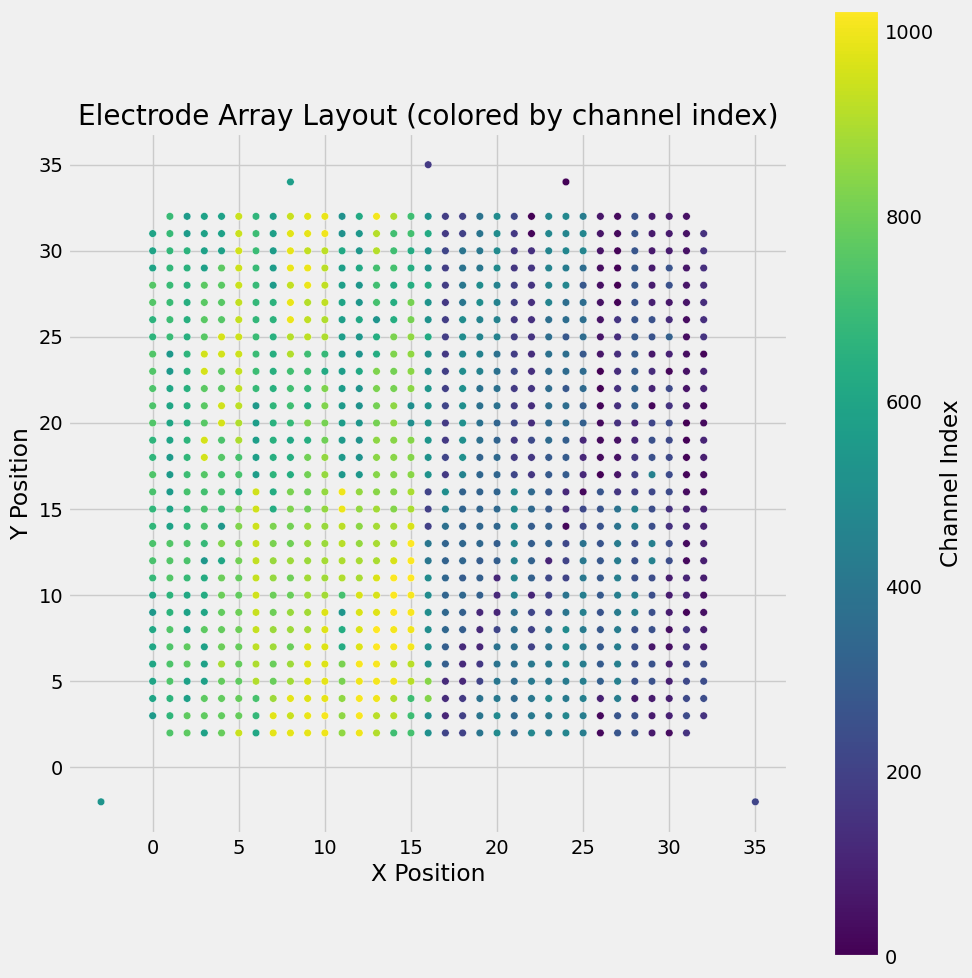

In [14]:
# Plot electrode layout with channel indices
fig, ax = plt.subplots(figsize=(10, 10))

# Color by channel index
scatter = ax.scatter(
    channel_coords[:, 0], 
    channel_coords[:, 1], 
    c=np.arange(N_CHANNELS),
    cmap='viridis',
    s=30,
    edgecolors='white',
    linewidths=0.3
)

ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Electrode Array Layout (colored by channel index)')
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='Channel Index')
plt.tight_layout()
plt.show()

## 4. Signal Statistics

In [15]:
# Compute basic statistics across all channels
data = train_features.values

print("Signal Statistics (Training Data):")
print(f"  Overall min: {data.min():.2f}")
print(f"  Overall max: {data.max():.2f}")
print(f"  Overall mean: {data.mean():.2f}")
print(f"  Overall std: {data.std():.2f}")

# Per-channel statistics
channel_means = data.mean(axis=0)
channel_stds = data.std(axis=0)

print(f"\nPer-channel mean: min={channel_means.min():.2f}, max={channel_means.max():.2f}")
print(f"Per-channel std: min={channel_stds.min():.2f}, max={channel_stds.max():.2f}")

Signal Statistics (Training Data):
  Overall min: -2193.26
  Overall max: 1555.42
  Overall mean: -0.23
  Overall std: 112.66

Per-channel mean: min=-0.53, max=0.06
Per-channel std: min=2.21, max=234.06


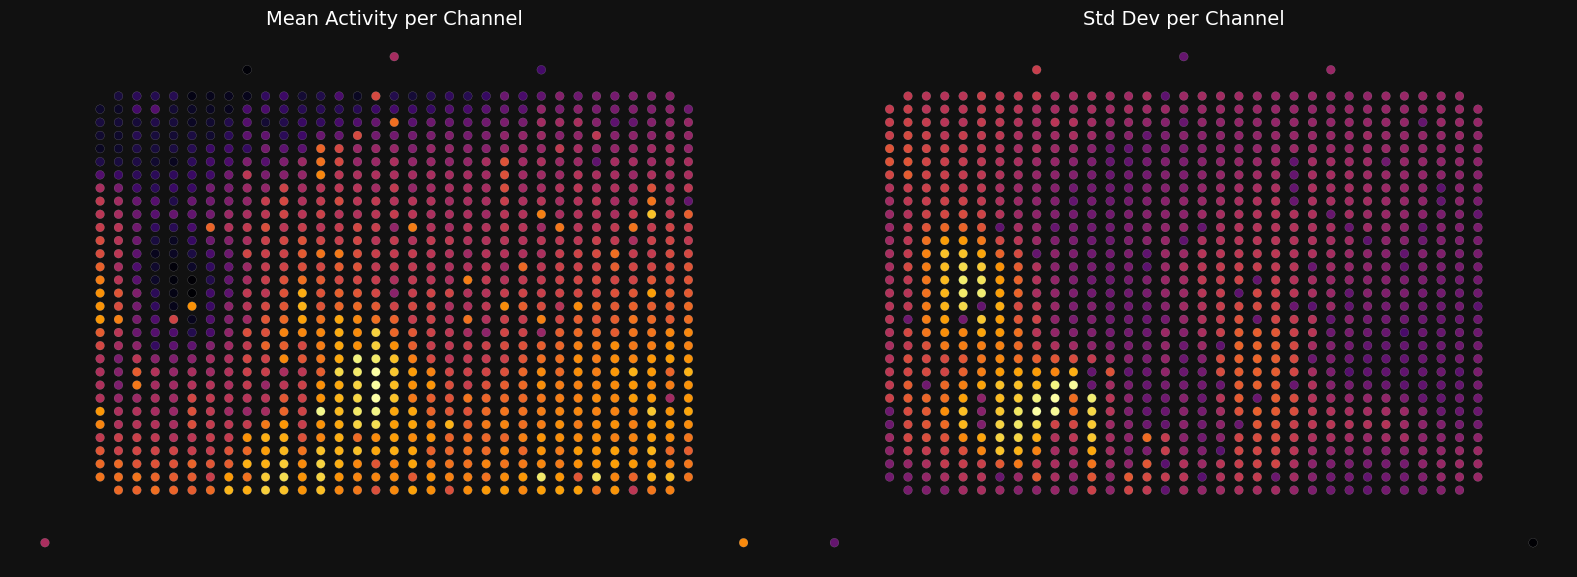

In [16]:
# Visualize channel statistics on the electrode array
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean activity
dot_plot(channel_means, channel_coords, ax=axes[0], marker_size=40)
axes[0].set_title('Mean Activity per Channel', color='white', fontsize=14)

# Standard deviation
dot_plot(channel_stds, channel_coords, ax=axes[1], marker_size=40)
axes[1].set_title('Std Dev per Channel', color='white', fontsize=14)

plt.tight_layout()
plt.show()

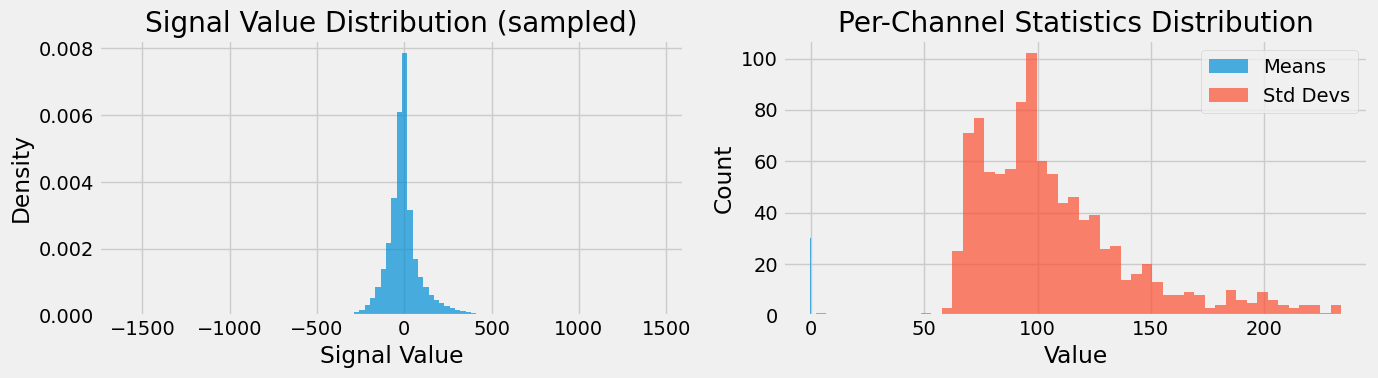

In [17]:
# Distribution of signal values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of all values (subsampled)
ax = axes[0]
sample_idx = np.random.choice(data.size, size=min(1000000, data.size), replace=False)
ax.hist(data.flatten()[sample_idx], bins=100, density=True, alpha=0.7)
ax.set_xlabel('Signal Value')
ax.set_ylabel('Density')
ax.set_title('Signal Value Distribution (sampled)')

# Channel mean distribution
ax = axes[1]
ax.hist(channel_means, bins=50, alpha=0.7, label='Means')
ax.hist(channel_stds, bins=50, alpha=0.7, label='Std Devs')
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.set_title('Per-Channel Statistics Distribution')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Time Series Visualization

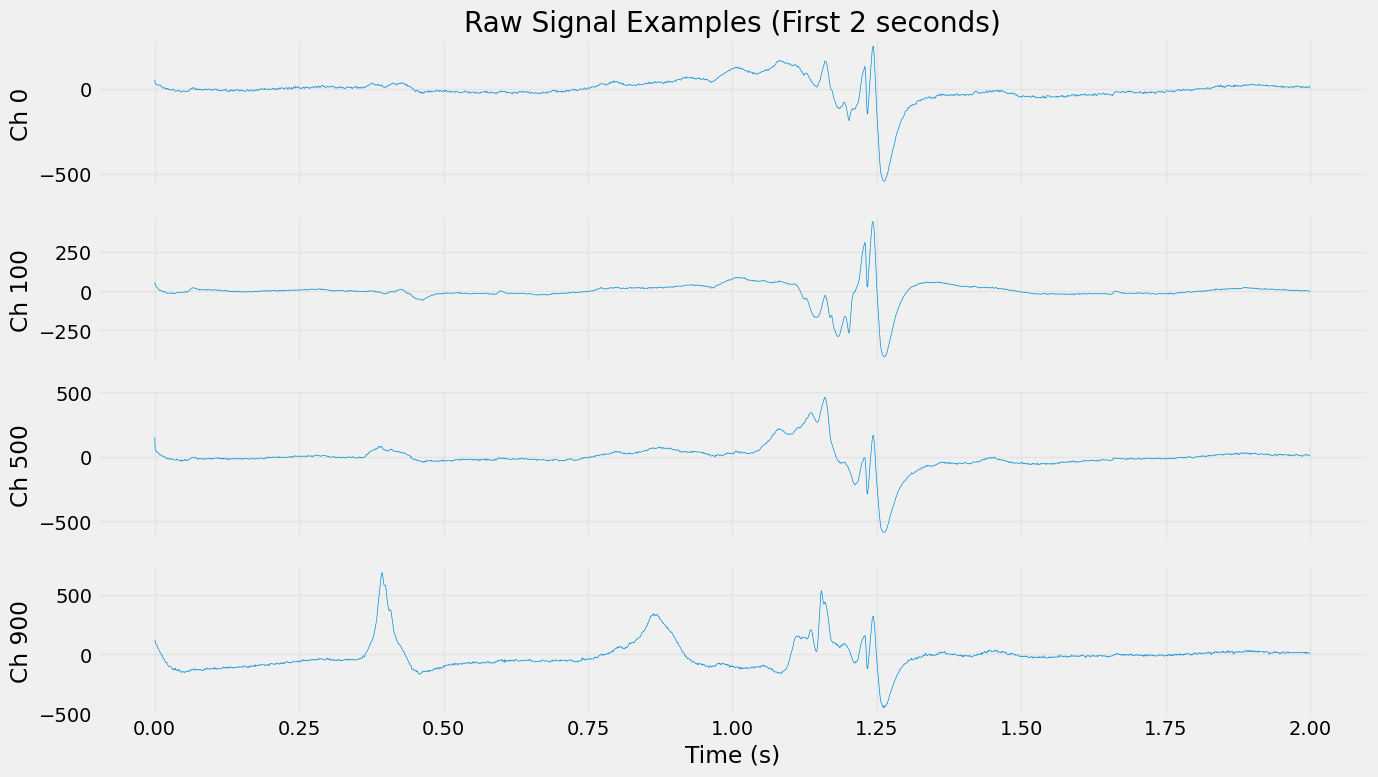

In [18]:
# Plot signals from a few channels
sample_channels = [0, 100, 500, 900]
time_window = (0, 2)  # First 2 seconds

# Get time indices
time_mask = (train_features.index >= time_window[0]) & (train_features.index <= time_window[1])
time_slice = train_features.index[time_mask]

fig, axes = plt.subplots(len(sample_channels), 1, figsize=(14, 8), sharex=True)

for i, ch in enumerate(sample_channels):
    ax = axes[i]
    ax.plot(time_slice, train_features.iloc[time_mask, ch], linewidth=0.5)
    ax.set_ylabel(f'Ch {ch}')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Raw Signal Examples (First 2 seconds)')

# Add stimulus overlay
for ax in axes:
    label_slice = train_labels.loc[time_mask, 'label']
    for t, label in zip(time_slice, label_slice):
        if label > 0:  # Stimulus present
            ax.axvspan(t, t + 0.001, alpha=0.1, color='red')

plt.tight_layout()
plt.show()

## 6. Spatial Activity Patterns

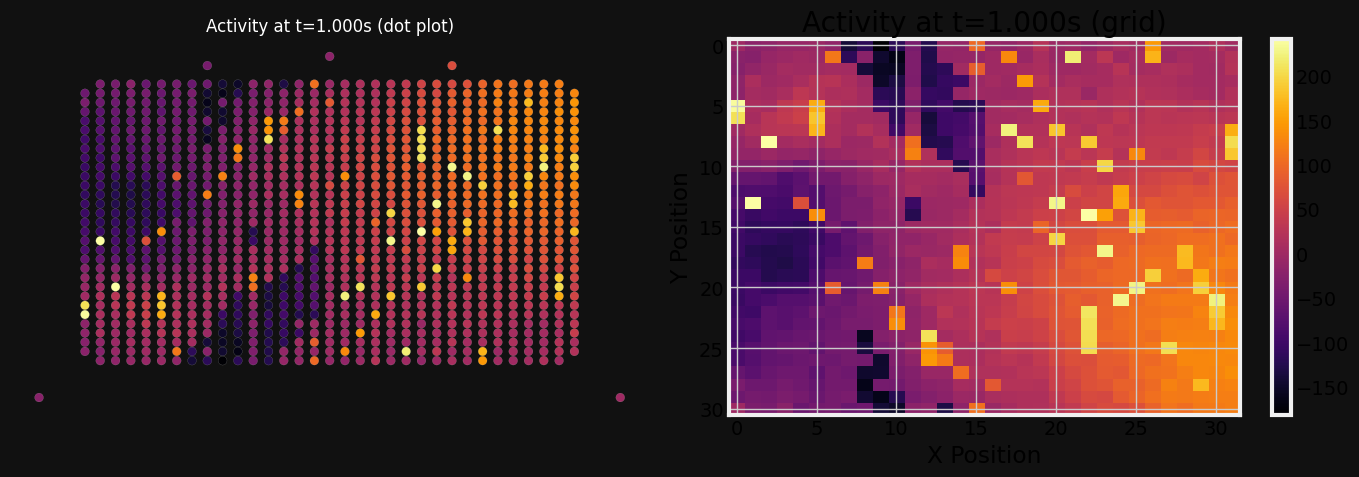

In [19]:
# Show spatial activity at a single time point
time_idx = 1000  # 1 second into recording
sample = train_features.iloc[time_idx].values

spatial_data = channels_to_spatial(sample, channel_coords)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dot plot
dot_plot(sample, channel_coords, ax=axes[0], marker_size=40)
axes[0].set_title(f'Activity at t={train_features.index[time_idx]:.3f}s (dot plot)', 
                  color='white', fontsize=12)

# Grid heatmap
im = axes[1].imshow(spatial_data, cmap='inferno', aspect='auto')
axes[1].set_xlabel('X Position')
axes[1].set_ylabel('Y Position')
axes[1].set_title(f'Activity at t={train_features.index[time_idx]:.3f}s (grid)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

## 7. Preprocessing Techniques

Common preprocessing steps for neural signals:

### 7.1 Z-Score Normalization

In [20]:
def zscore_normalize(data, axis=0):
    """Z-score normalize along specified axis."""
    mean = data.mean(axis=axis, keepdims=True)
    std = data.std(axis=axis, keepdims=True)
    return (data - mean) / (std + 1e-8)

# Apply z-score normalization per channel
data_zscore = zscore_normalize(data, axis=0)

print("After Z-score normalization (per channel):")
print(f"  Mean: {data_zscore.mean():.6f}")
print(f"  Std: {data_zscore.std():.6f}")
print(f"  Min: {data_zscore.min():.2f}")
print(f"  Max: {data_zscore.max():.2f}")

After Z-score normalization (per channel):
  Mean: -0.000000
  Std: 1.000000
  Min: -25.25
  Max: 16.92


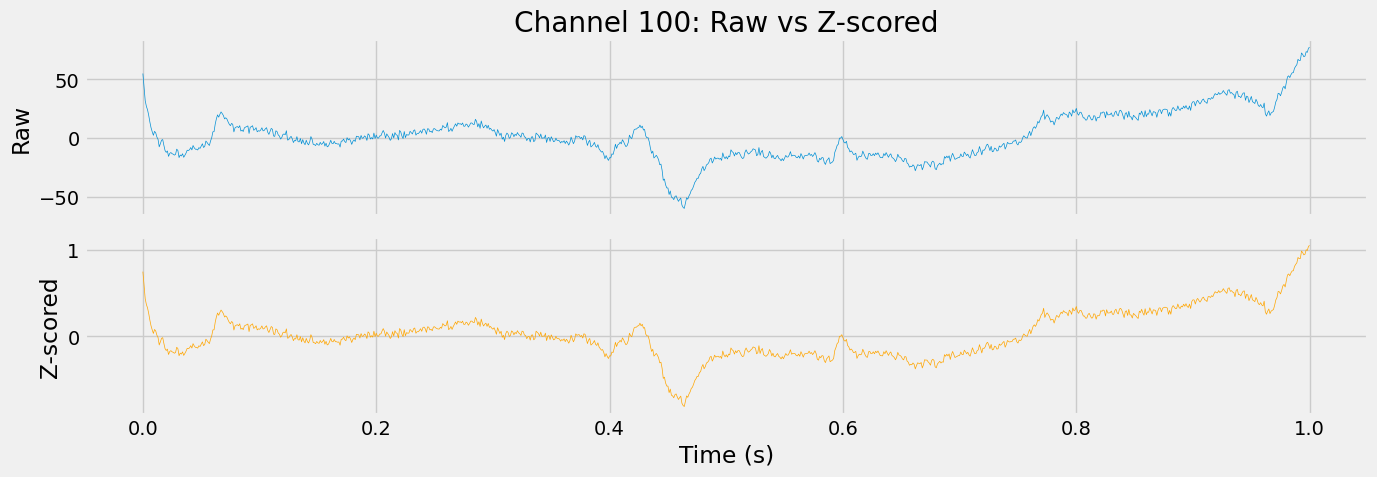

In [21]:
# Compare raw vs normalized
ch = 100
t_start, t_end = 0, 1  # First second
mask = (train_features.index >= t_start) & (train_features.index <= t_end)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(train_features.index[mask], data[mask, ch], linewidth=0.5)
axes[0].set_ylabel('Raw')
axes[0].set_title(f'Channel {ch}: Raw vs Z-scored')

axes[1].plot(train_features.index[mask], data_zscore[mask, ch], linewidth=0.5, color='orange')
axes[1].set_ylabel('Z-scored')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### 7.2 Bandpass Filtering

In [22]:
def bandpass_filter(data, low_freq, high_freq, fs, order=4):
    """Apply bandpass filter to data."""
    nyquist = fs / 2
    low = low_freq / nyquist
    high = high_freq / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data, axis=0)

# Filter to common neural frequency bands
# Note: Using a small subset for speed
subset = data[:5000, :100]  # First 5 seconds, first 100 channels

# Gamma band (30-100 Hz) - often important for auditory processing
gamma = bandpass_filter(subset, 30, 100, SAMPLING_RATE)

# High gamma (70-150 Hz) - correlates with local neural activity
high_gamma = bandpass_filter(subset, 70, 150, SAMPLING_RATE)

print("Filtered data shapes:")
print(f"  Gamma (30-100 Hz): {gamma.shape}")
print(f"  High Gamma (70-150 Hz): {high_gamma.shape}")

Filtered data shapes:
  Gamma (30-100 Hz): (5000, 100)
  High Gamma (70-150 Hz): (5000, 100)


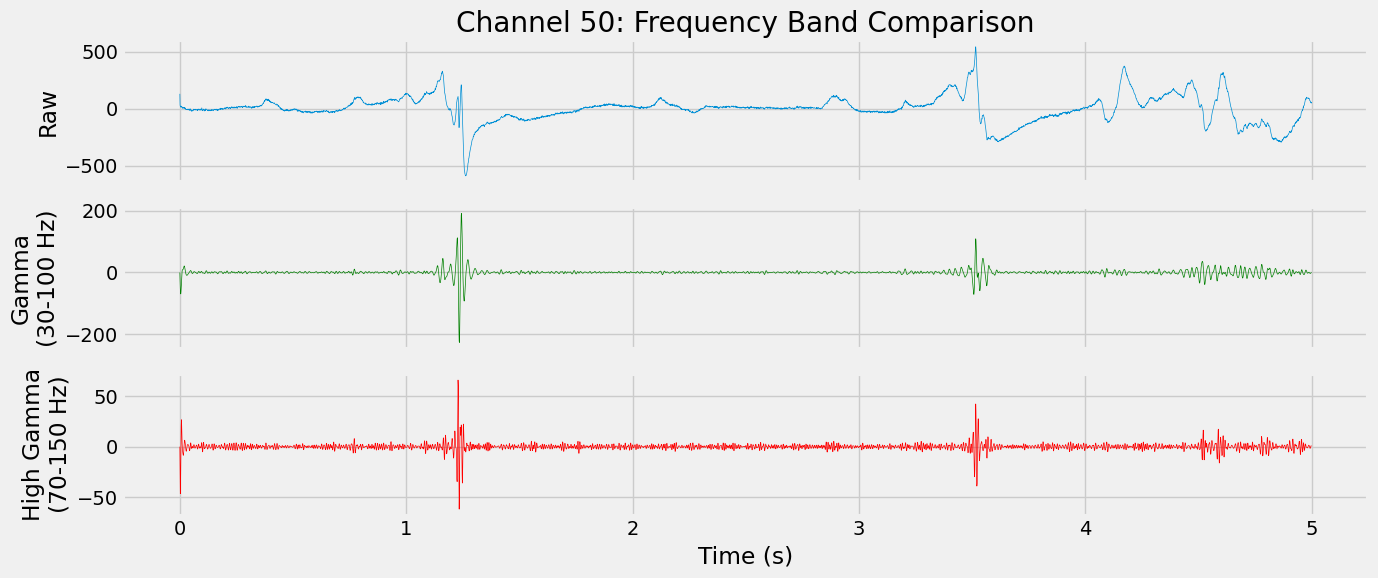

In [23]:
# Compare filtered signals
ch = 50
t = np.arange(subset.shape[0]) / SAMPLING_RATE

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, subset[:, ch], linewidth=0.5)
axes[0].set_ylabel('Raw')
axes[0].set_title(f'Channel {ch}: Frequency Band Comparison')

axes[1].plot(t, gamma[:, ch], linewidth=0.5, color='green')
axes[1].set_ylabel('Gamma\n(30-100 Hz)')

axes[2].plot(t, high_gamma[:, ch], linewidth=0.5, color='red')
axes[2].set_ylabel('High Gamma\n(70-150 Hz)')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### 7.3 Power Spectral Density

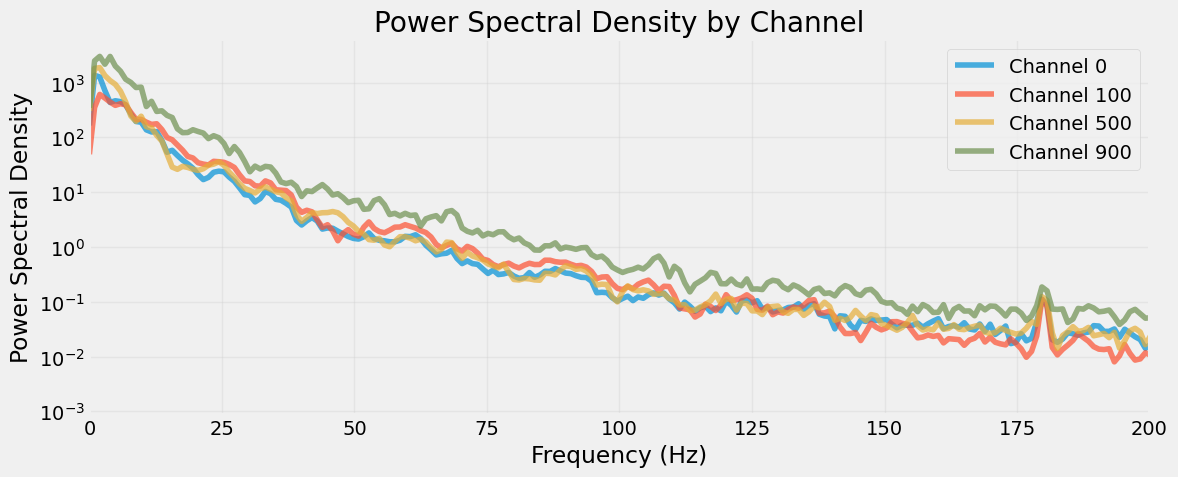

In [24]:
# Compute PSD for a few channels
sample_channels = [0, 100, 500, 900]

fig, ax = plt.subplots(figsize=(12, 5))

for ch in sample_channels:
    freqs, psd = signal.welch(data[:10000, ch], fs=SAMPLING_RATE, nperseg=1024)
    ax.semilogy(freqs, psd, label=f'Channel {ch}', alpha=0.7)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density')
ax.set_title('Power Spectral Density by Channel')
ax.legend()
ax.set_xlim(0, 200)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.4 Common Average Reference (CAR)

In [25]:
def common_average_reference(data):
    """Apply common average reference to remove global noise."""
    mean_across_channels = data.mean(axis=1, keepdims=True)
    return data - mean_across_channels

# Apply CAR
data_car = common_average_reference(data[:5000])

print("After Common Average Reference:")
print(f"  Mean per timepoint: {data_car.mean(axis=1).mean():.6f}")
print(f"  Std: {data_car.std():.2f}")

After Common Average Reference:
  Mean per timepoint: -0.000001
  Std: 101.12


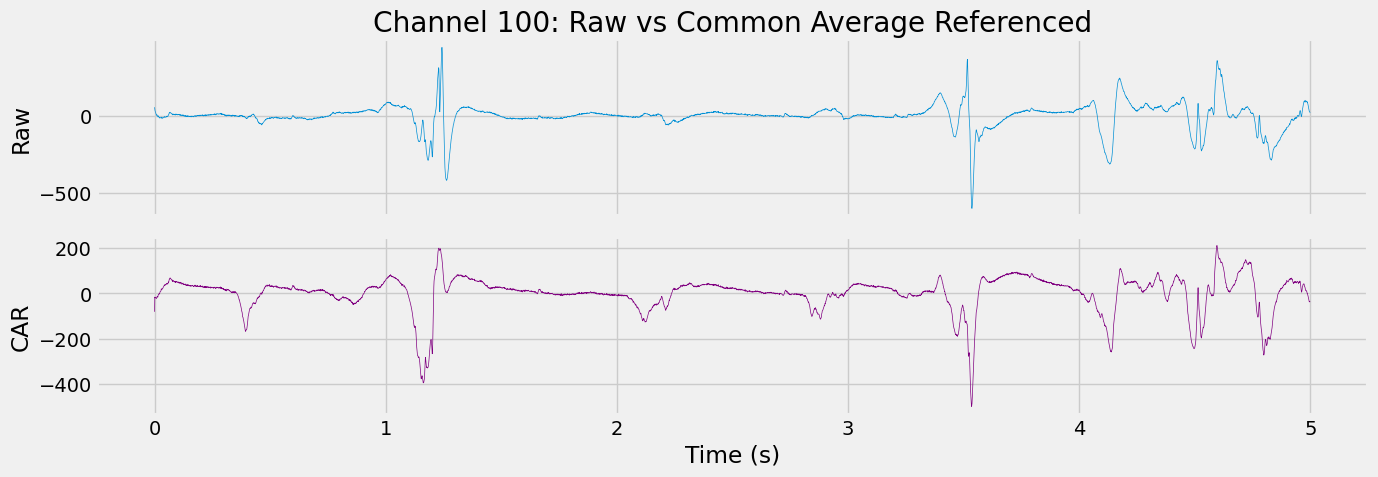

In [26]:
# Compare raw vs CAR
ch = 100
t = np.arange(5000) / SAMPLING_RATE

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(t, data[:5000, ch], linewidth=0.5)
axes[0].set_ylabel('Raw')
axes[0].set_title(f'Channel {ch}: Raw vs Common Average Referenced')

axes[1].plot(t, data_car[:, ch], linewidth=0.5, color='purple')
axes[1].set_ylabel('CAR')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### 7.5 Dimensionality Reduction (PCA)

In [27]:
from sklearn.decomposition import PCA

# Use a subset for PCA demonstration
subset = data[:10000]  # First 10 seconds

# Fit PCA
pca = PCA(n_components=100)
data_pca = pca.fit_transform(subset)

print(f"Original shape: {subset.shape}")
print(f"PCA reduced shape: {data_pca.shape}")
print(f"\nExplained variance ratio (first 10 components):")
for i, var in enumerate(pca.explained_variance_ratio_[:10]):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"\nTotal variance explained (100 components): {pca.explained_variance_ratio_.sum()*100:.1f}%")

Original shape: (10000, 1024)
PCA reduced shape: (10000, 100)

Explained variance ratio (first 10 components):
  PC1: 44.11%
  PC2: 15.97%
  PC3: 12.51%
  PC4: 8.60%
  PC5: 4.83%
  PC6: 2.94%
  PC7: 2.54%
  PC8: 1.37%
  PC9: 1.22%
  PC10: 0.90%

Total variance explained (100 components): 99.9%


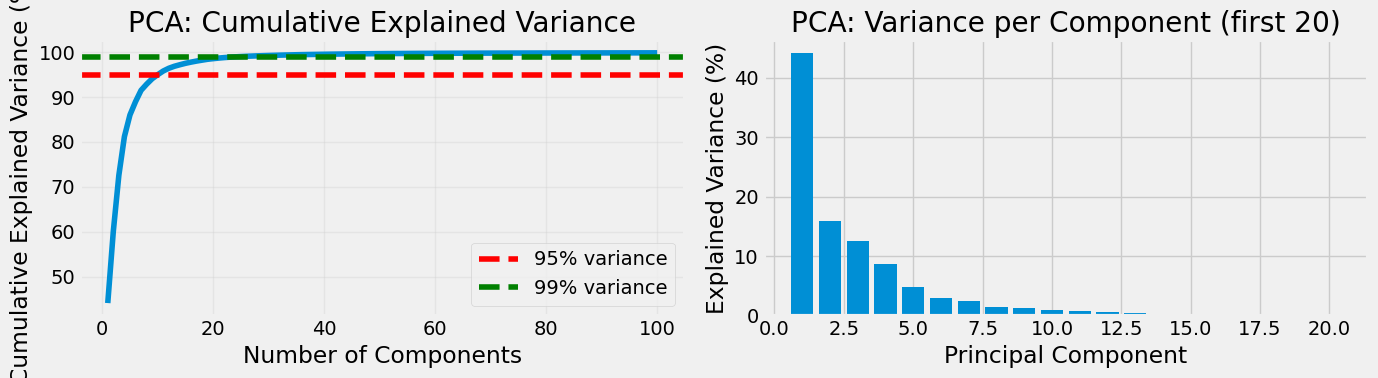

In [28]:
# Plot cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cumulative variance
ax = axes[0]
cumsum = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, 101), cumsum * 100)
ax.axhline(y=95, color='r', linestyle='--', label='95% variance')
ax.axhline(y=99, color='g', linestyle='--', label='99% variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA: Cumulative Explained Variance')
ax.legend()
ax.grid(True, alpha=0.3)

# Individual variance
ax = axes[1]
ax.bar(range(1, 21), pca.explained_variance_ratio_[:20] * 100)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA: Variance per Component (first 20)')

plt.tight_layout()
plt.show()

## 8. Signal During Different Stimuli

In [29]:
# Compare average activity during different stimulus frequencies
unique_labels = sorted(train_labels['label'].unique())

# Compute mean activity per stimulus condition
mean_activity = {}
for label in unique_labels:
    mask = train_labels['label'].values == label
    mean_activity[label] = data[mask].mean(axis=0)

print("Mean activity computed for each stimulus:")
for label in unique_labels:
    print(f"  {label} Hz: shape {mean_activity[label].shape}")

Mean activity computed for each stimulus:
  0.0 Hz: shape (1024,)
  120.0 Hz: shape (1024,)
  224.0 Hz: shape (1024,)
  421.0 Hz: shape (1024,)
  789.0 Hz: shape (1024,)
  1479.0 Hz: shape (1024,)
  2772.0 Hz: shape (1024,)
  5195.0 Hz: shape (1024,)
  9736.0 Hz: shape (1024,)


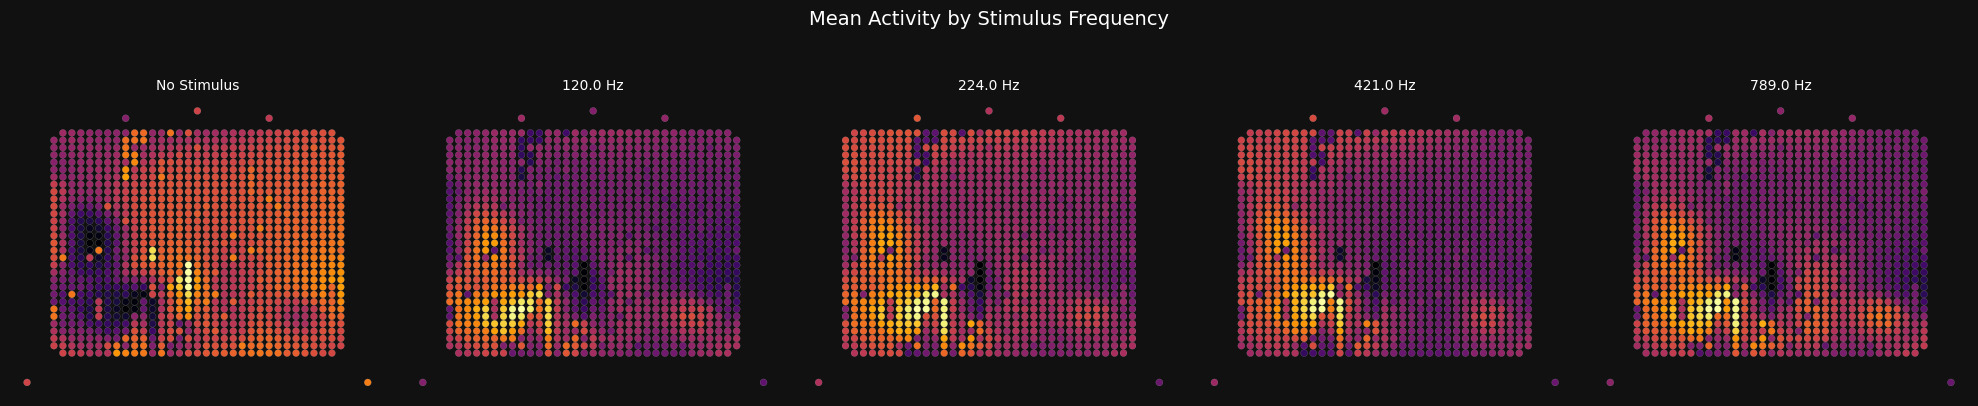

In [30]:
# Visualize spatial activity patterns for different stimuli
stim_labels = [l for l in unique_labels if l > 0][:4]  # First 4 non-zero stimuli

fig, axes = plt.subplots(1, len(stim_labels) + 1, figsize=(4 * (len(stim_labels) + 1), 4))

# No stimulus
dot_plot(mean_activity[0], channel_coords, ax=axes[0], marker_size=25)
axes[0].set_title('No Stimulus', color='white', fontsize=10)

# Different frequencies
for i, label in enumerate(stim_labels):
    dot_plot(mean_activity[label], channel_coords, ax=axes[i+1], marker_size=25)
    axes[i+1].set_title(f'{label} Hz', color='white', fontsize=10)

plt.suptitle('Mean Activity by Stimulus Frequency', color='white', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Summary

Key observations and preprocessing recommendations:

1. **Data Scale**: Raw values are in voltage units; z-score normalization helps standardize
2. **Spatial Structure**: 1024 channels arranged in ~31x32 grid with meaningful spatial patterns
3. **Temporal Resolution**: 1000 Hz sampling captures fast neural dynamics
4. **Frequency Content**: Rich spectral content; gamma/high-gamma bands may be informative
5. **Dimensionality**: PCA shows ~100 components capture most variance (channel reduction viable)
6. **Stimulus Responses**: Different frequencies produce distinct spatial activation patterns

In [ ]:
print("Notebook complete!")